## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [1]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [3]:

element = 'Tl'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [4]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[11.18,
 11.4,
 11.98,
 12.64,
 12.88,
 13.22,
 13.94,
 13.98,
 14.86,
 14.93,
 15.32,
 15.66,
 16.08,
 17.5,
 17.78,
 18.24,
 18.36,
 18.8,
 19.86,
 20.6,
 20.7,
 21.7,
 23.6,
 25.0,
 27.5,
 29.2,
 33.0,
 34.5,
 38.7,
 40.6,
 44.9,
 47.2,
 52.3,
 54.0,
 59.2,
 61.4,
 66.1,
 69.0,
 77.5,
 94.0,
 96.2,
 103.5,
 118.4,
 123.2,
 132.8,
 139.8,
 147.8,
 236.6,
 246.6,
 249.0,
 0.411,
 0.4325,
 1.14,
 1.26,
 1.421,
 1.519,
 1.599,
 1.726,
 1.839,
 1.932,
 2.014,
 2.133,
 2.232,
 2.327,
 2.37,
 2.419,
 2.487,
 2.572,
 2.738,
 3.001,
 3.28,
 3.67,
 4.103,
 1.162,
 1.222,
 1.289,
 1.382,
 1.434,
 1.538,
 1.647,
 1.718,
 1.798,
 1.932,
 2.154,
 2.233,
 2.52,
 2.778,
 1.109,
 1.204,
 1.318,
 1.604,
 1.852,
 2.073,
 2.259,
 2.361,
 2.443,
 2.6,
 0.4895,
 0.5154,
 0.5662,
 0.6015,
 0.6442,
 0.6886,
 0.7274,
 0.8124,
 0.8591,
 0.9297,
 0.9779,
 1.031,
 0.5159,
 0.5589,
 0.5868,
 0.6223,
 0.6556,
 0.7106,
 0.7709,
 0.8499,
 0.9431,
 1.036,
 0.6407,
 0.725,
 0.7944,
 0.9167,
 0.9925,
 300.53,
 58.27,

In [5]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [6]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [7]:
Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [8]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = data['Temp'].values
cp = data['Heat capacity at constant pressure Cp: J/K/mol'].values



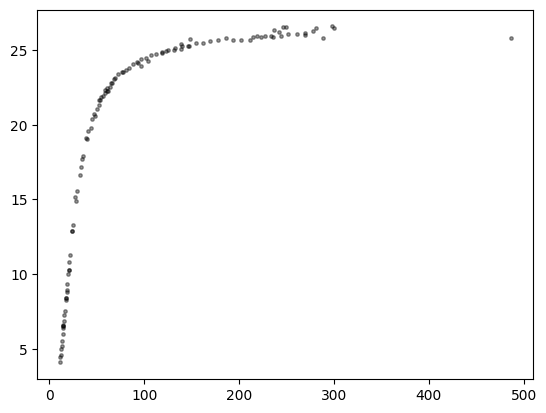

In [9]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [10]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
initial_5params = [300, 1e-3, 0.01, 800, 300]
#initial_5params = [225, 1e-4, 1e-3, 150, 350]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [11]:
from espei.pureElement import log_probability

In [12]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 4000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


100%|██████████| 4000/4000 [00:15<00:00, 260.79it/s]


State([[ 6.64567945e+01  4.90724917e-03  1.18943183e-02  6.65335803e+50
   6.65335803e+50]
 [ 6.77417938e+01  4.69545219e-03  9.99104524e-02  1.00483769e+51
   1.00483769e+51]
 [ 6.75411132e+01  3.96469767e-03  1.94332064e-03 -1.23620174e+51
  -1.23620174e+51]
 [ 6.71158725e+01  4.26179851e-03  2.65892619e-02  1.98617143e+51
   1.98617143e+51]
 [ 6.75773712e+01  3.53458083e-03  4.09517834e-03  8.72640549e+50
   8.72640549e+50]
 [ 6.71857259e+01  5.28090545e-03  7.38025163e-02 -6.56198927e+51
  -6.56198927e+51]
 [ 6.61285978e+01  4.80463184e-03  8.16644517e-02  4.26976216e+51
   4.26976216e+51]
 [ 6.78342879e+01  4.82039634e-03  6.78380263e-02  1.80828649e+51
   1.80828649e+51]
 [ 6.94726029e+01  3.33710572e-03  3.35807427e-02  3.25519308e+51
   3.25519308e+51]
 [ 6.78393777e+01  3.58857515e-03  7.60216201e-02  1.49187726e+51
   1.49187726e+51]
 [ 6.87117631e+01  5.08402797e-03  6.22042459e-02  2.49811192e+51
   2.49811192e+51]
 [ 6.61011326e+01  5.01589739e-03  9.86303120e-02  2.235133

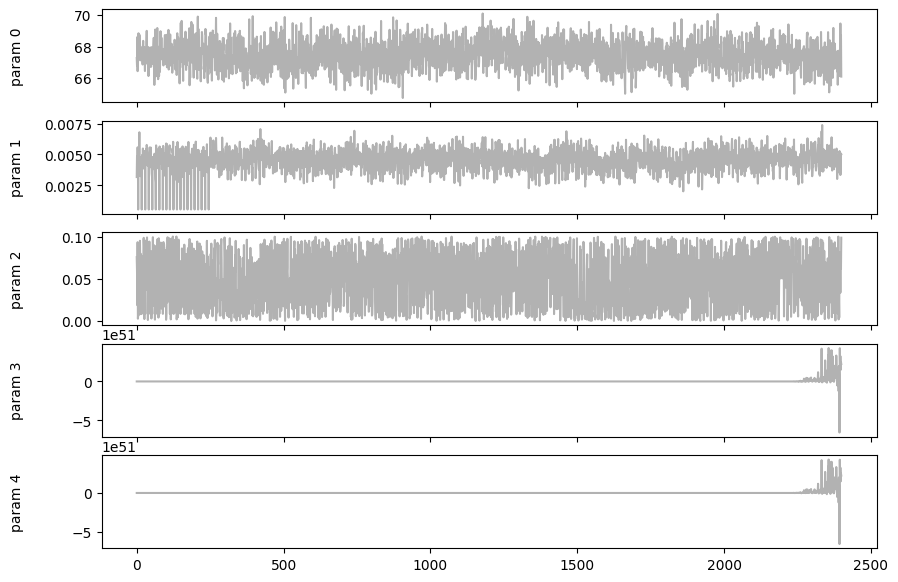

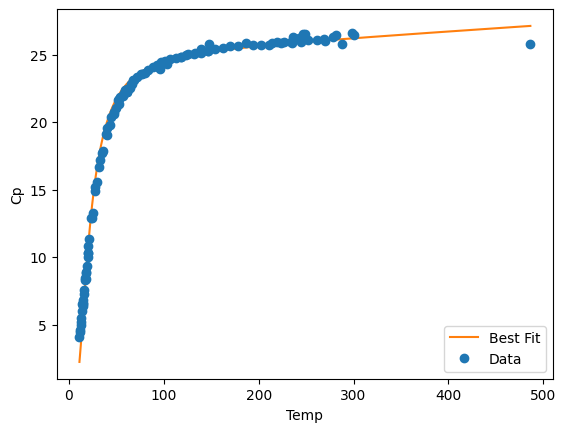

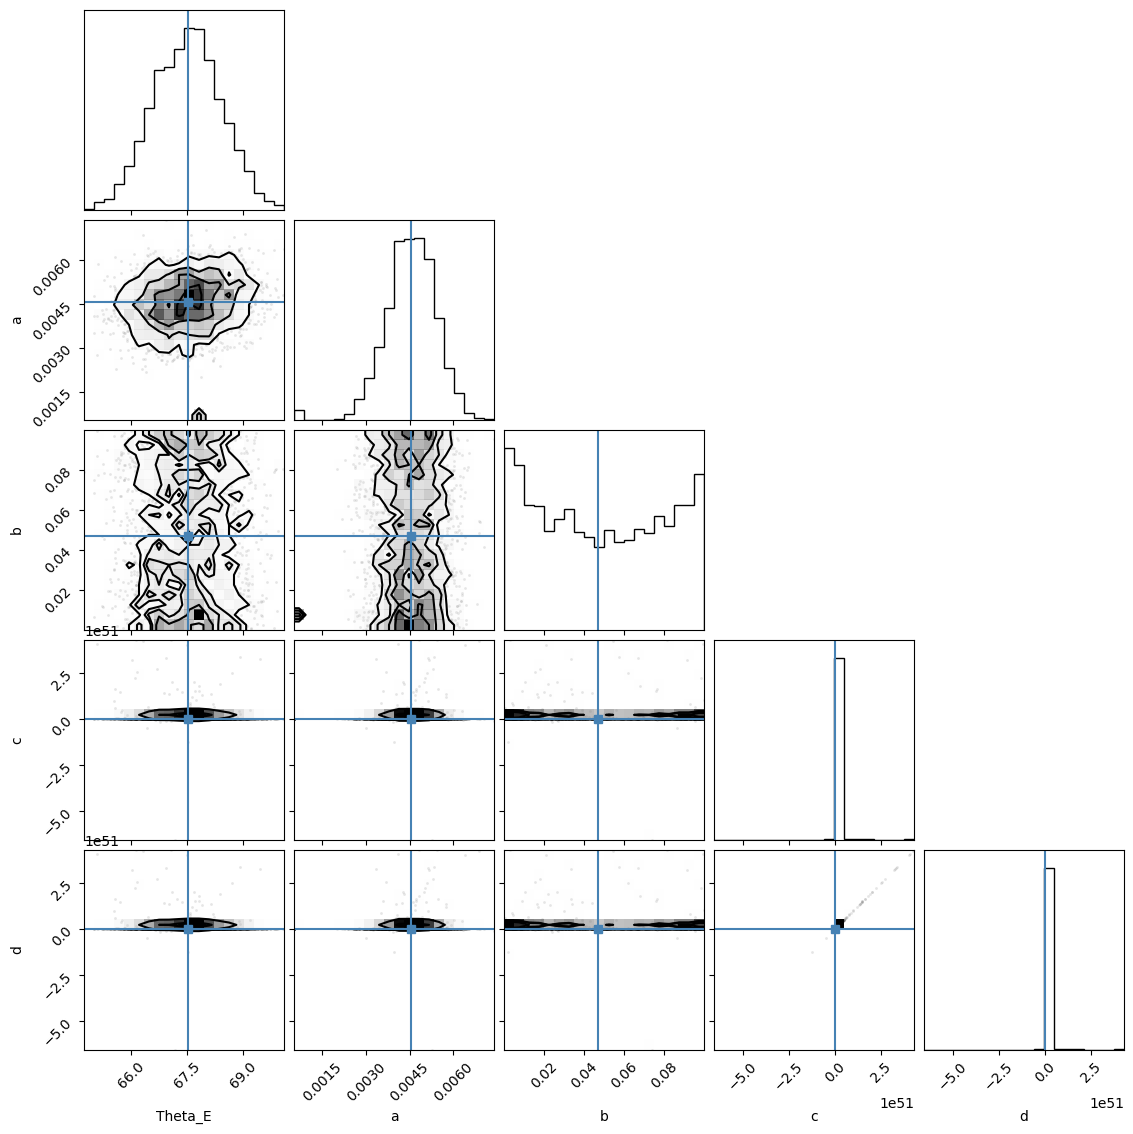

In [13]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)
log_prob = sampler.get_log_prob(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


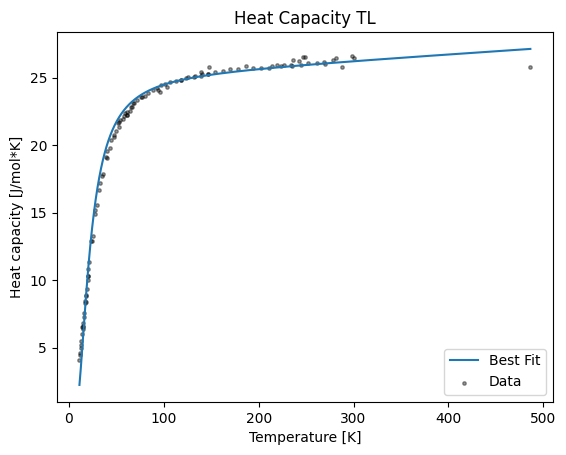

In [14]:
# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [15]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([6.75294502e+01, 4.56175976e-03, 4.70850539e-02, 1.26143605e+16,
       2.78576849e+15])

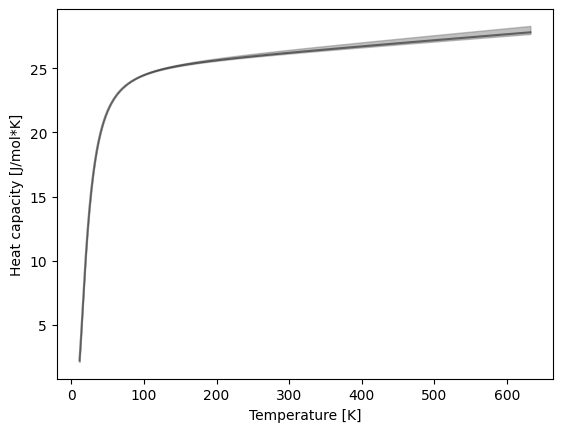

In [16]:
best_params = samples[np.argmax(log_prob)]
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [17]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [18]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 0.8963298703904707
Standard deviation of a: 0.000875875055560216
Standard deviation of b: 0.03124450570513361
Standard deviation of c: 3.195826434363492e+50
Standard deviation of d: 3.195826434363479e+50


In [19]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[6.70593195e+01 4.21621815e-03 1.44340541e-11]
 [6.60626615e+01 2.89443328e-03 8.36855691e-12]
 [6.77830385e+01 4.50495092e-03 2.44248017e-12]
 [6.70725493e+01 3.39870769e-03 7.65423210e-12]
 [6.75332892e+01 4.59947581e-03 9.67513749e-12]
 [6.76361264e+01 4.33623306e-03 7.52489796e-12]
 [6.65782549e+01 4.37272840e-03 4.55494110e-12]
 [6.74229511e+01 4.73855954e-03 1.17461598e-11]
 [6.75522851e+01 5.38970254e-03 7.16374540e-12]
 [6.67184118e+01 3.63188314e-03 4.80859910e-13]
 [6.75254655e+01 5.01035065e-03 6.88804946e-12]
 [6.76962947e+01 2.75036615e-03 2.80686107e-11]
 [6.73923208e+01 5.39480507e-03 2.19897768e-11]
 [6.72456418e+01 4.08489408e-03 1.15140139e-11]
 [6.69144358e+01 4.11627317e-03 2.88077915e-11]
 [6.72991159e+01 4.74283225e-03 2.33008690e-12]
 [6.77997711e+01 4.55520622e-03 6.24403721e-12]
 [6.75782988e+01 4.48566132e-03 4.89517322e-12]
 [6.61084486e+01 3.37274008e-03 2.15471769e-11]
 [6.80142982e+01 3.75418035e-03 2.49664386e-11]
 [6.68508039e+01 4.04891381e-03 2.

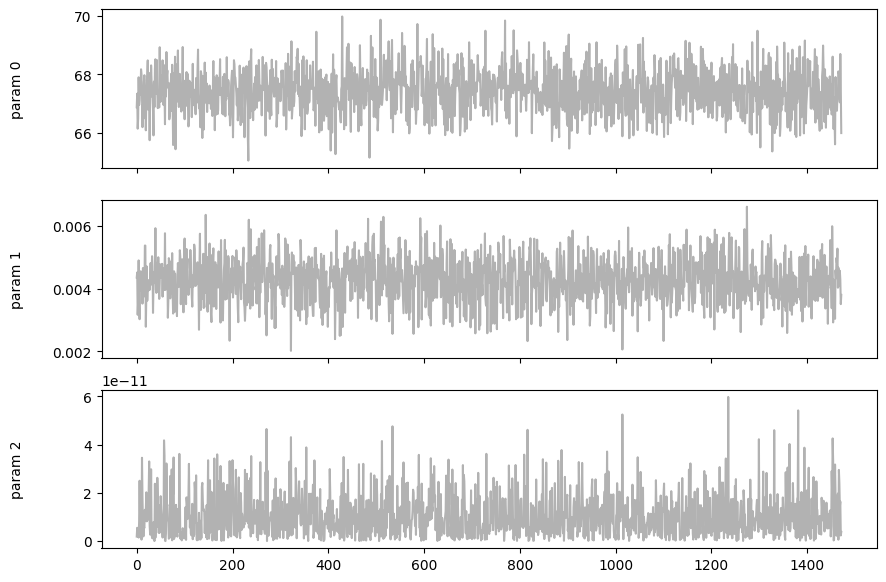

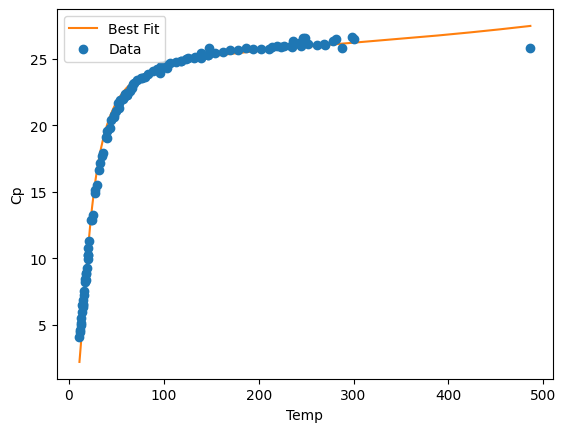

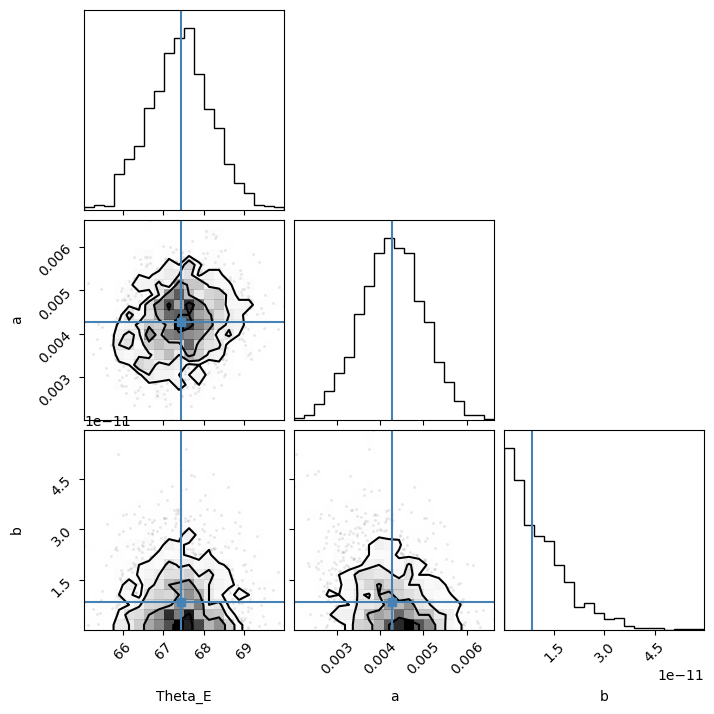

In [20]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)
log_prob2 = sampler2.get_log_prob(flat=True, discard=300, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = samples2[np.argmax(log_prob2)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


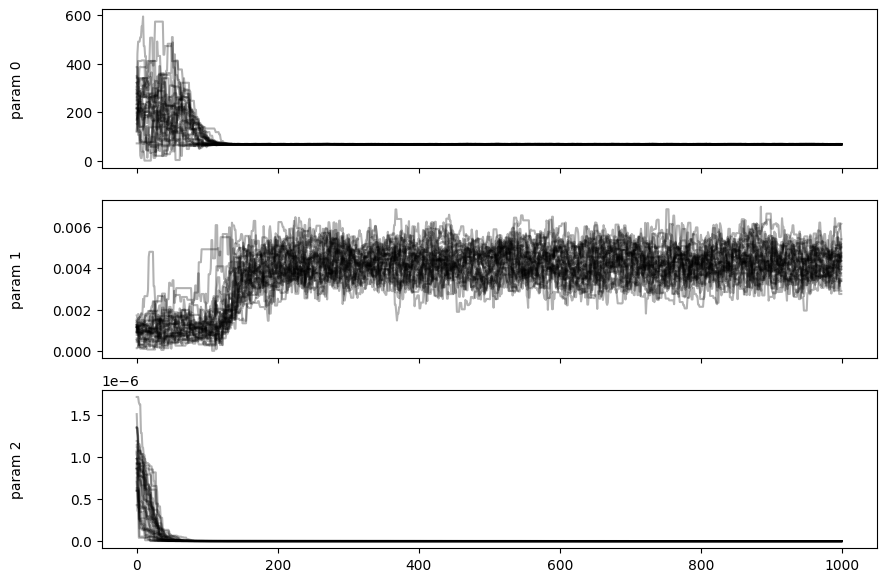

In [21]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([6.74348540e+01, 4.27407968e-03, 8.43078672e-12])

In [23]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[6.62644268e+01 5.74229489e-03 3.12216912e-07]
 [6.75733041e+01 3.35167441e-03 2.56980329e-06]
 [6.61644739e+01 3.27839913e-03 5.20614845e-06]
 [6.70296831e+01 4.65225404e-03 6.24523044e-07]
 [6.80010939e+01 3.06513814e-03 9.69344189e-06]
 [6.64510761e+01 2.35106405e-03 8.58500398e-06]
 [6.55414665e+01 1.46608968e-03 1.44336364e-05]
 [6.90521179e+01 5.57421990e-03 4.67017625e-08]
 [6.88516209e+01 4.18793827e-03 4.20965828e-07]
 [6.64824228e+01 2.55455756e-03 7.90183881e-06]
 [6.64641632e+01 4.19303230e-03 1.33611953e-06]
 [6.66978086e+01 2.27450074e-03 9.22516253e-06]
 [6.79199047e+01 1.33743511e-03 1.23188410e-05]
 [6.65747901e+01 3.28134979e-03 1.41490286e-06]
 [6.71142646e+01 4.01936296e-03 6.25120186e-06]
 [6.60207752e+01 2.93439143e-03 2.94648474e-06]
 [6.79080345e+01 2.74282164e-03 4.93553831e-06]
 [6.76140724e+01 3.23200509e-03 3.05570995e-06]
 [6.63288317e+01 2.95699909e-03 5.49650665e-06]
 [6.65695200e+01 3.17574921e-03 3.88375606e-06]
 [6.76509786e+01 5.92090312e-03 1.

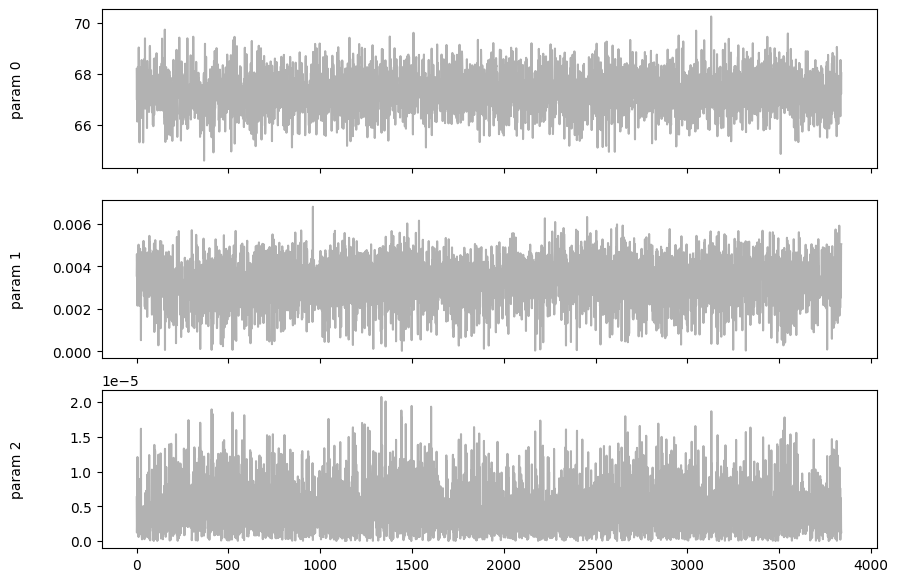

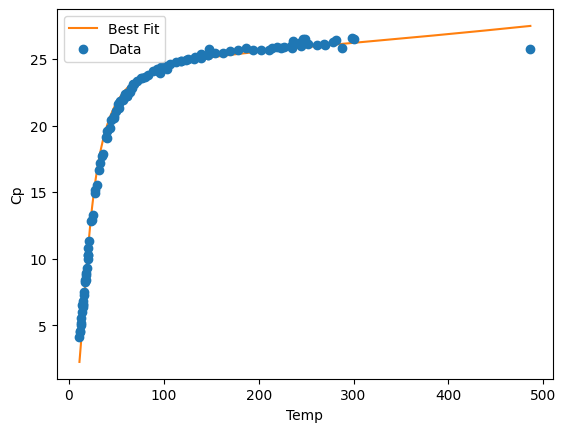

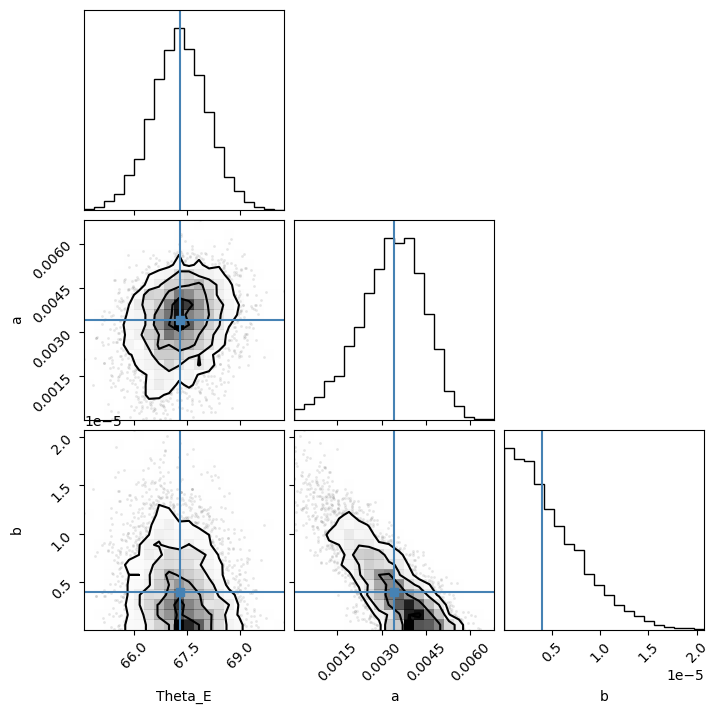

In [24]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)
log_prob3 = sampler3.get_log_prob(flat=True, discard=200, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


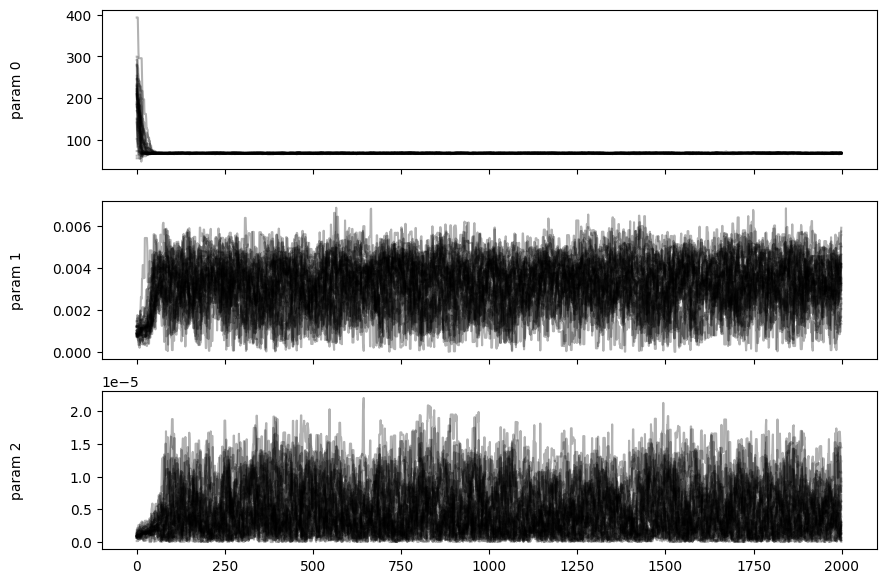

In [25]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [26]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[6.73007017e+01 3.40409288e-03 3.91038504e-06]


<IPython.core.display.Math object>

...

[6.74348540e+01 4.27407968e-03 8.43078672e-12]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[6.75294502e+01 4.56175976e-03 4.70850539e-02 1.26143605e+16
 2.78576849e+15]


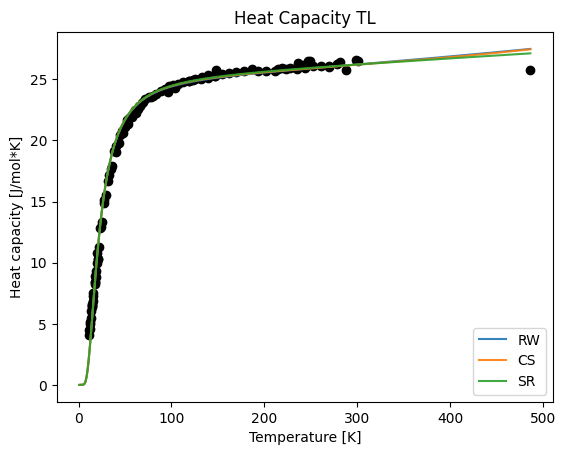

In [27]:
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [28]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [29]:
print(RW[0],CS[0],SR[0])

0.0283350534687182 0.035535845196657374 0.03792769446656332


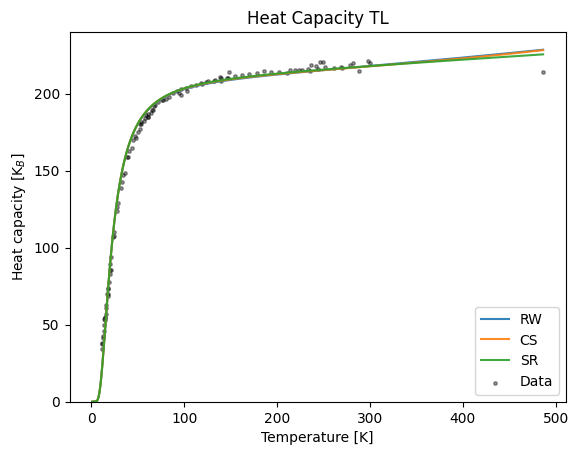

In [30]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

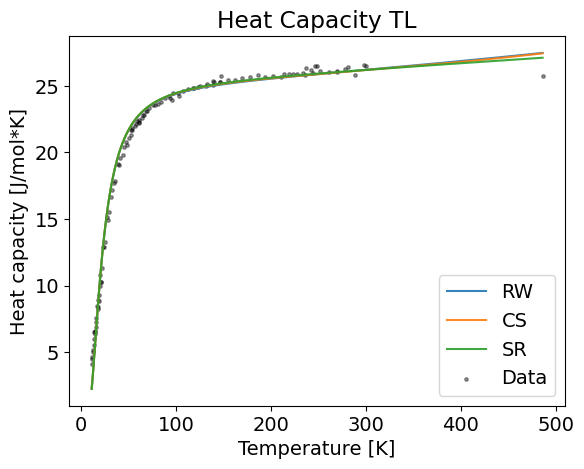

In [31]:
plt.rcParams.update({'font.size': 14})
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


-185.84542310707212 <class 'numpy.ndarray'> 200
0.003406048076233538 <class 'numpy.ndarray'> 200
sr


Text(0.5, 1.0, 'Gibbs TL')

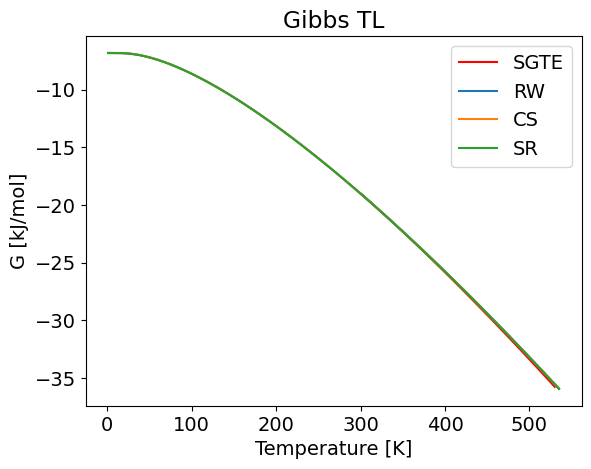

In [32]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

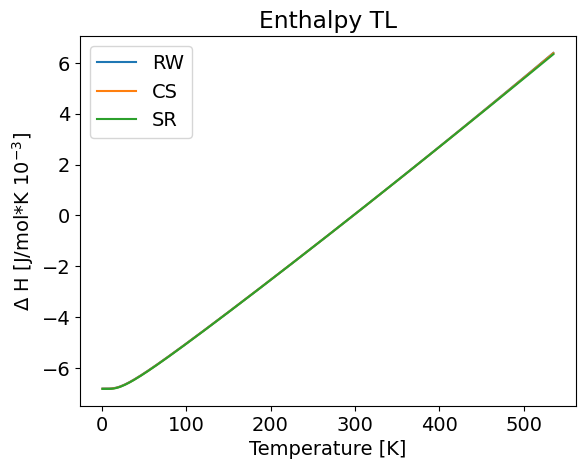

In [33]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

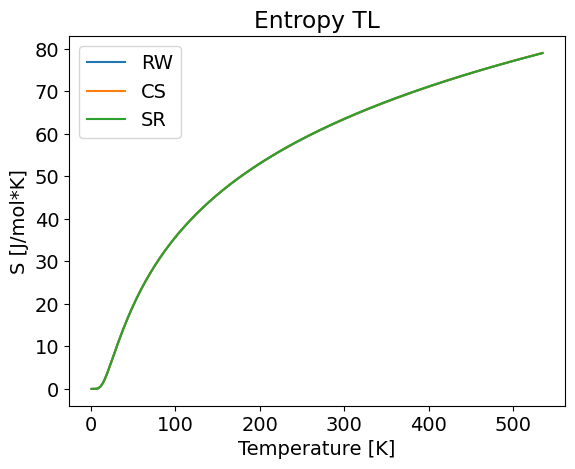

In [34]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [35]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [36]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 113
aic2: 53.8624985723742
correction:  0.22018348623853212
k= 3 n= 113
aic2: 54.314847858166665
correction:  0.22018348623853212
k= 5 n= 113
aic2: 57.22825399099033
correction:  0.5607476635514018


In [37]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 54.08268205861273
AICC_CS: 54.5350313444052
AICC_SR: 57.789001654541735


In [38]:
output_file='41_Elements/HCP/Results/'+element+'_output.json'
params={'CS':best_params2.tolist(),'RW':best_params3.tolist(),'SR':best_params.tolist(),'AICC_RW':AICC_RW,'AICC_CS':AICC_CS,'AICC_SR':AICC_SR}
with open(output_file, 'w') as f:
    json.dump(params, f, indent=4)